In [1]:
import numpy as np
import matplotlib.pyplot as plt
from specs import *
from meer21cm import MockSimulation
from func_00 import *
from meer21cm.telescope import dish_beam_sigma
from scipy.optimize import curve_fit

/home/zchen/miniconda3/envs/meer21cm/lib/python3.10/site-packages/halomod/halo_model.py:32: UserWarning: Warning: Some Halo-Exclusion models have significant speedup when using Numba
  from .halo_exclusion import Exclusion, NoExclusion


In [2]:
def get_k_modes():
    mock = MockSimulation(
        wproj=wcs,
        num_pix_x=num_pix_x,
        num_pix_y=num_pix_y,
        ra_range=ra_range,
        dec_range=dec_range,
        nu=nu_arr,
        mean_amp_1="average_hi_temp",
        omega_hi=5e-4,
    )
    mock.downres_factor_transverse = 3
    mock.downres_factor_radial = 6
    mock.get_enclosing_box()
    mock.k1dbins = k1dbins
    mock.kperpbins = kperpbins
    mock.kparabins = kparabins
    box_len = mock.box_len.copy()
    box_ndim = mock.box_ndim.copy()
    box_resol = mock.box_resol.copy()
    split_indx = box_ndim[1]//2
    mock._box_ndim = np.array([box_ndim[0],split_indx,box_ndim[2]])
    mock._box_len = mock._box_ndim * box_resol
    mock.propagate_field_k_to_model()
    kperp_1 = mock.k_perp.copy()
    kpara_1 = mock.k_para.copy()
    kmode_1 = mock.k_mode.copy()
    kvec_1 = mock.k_vec.copy()
    mock._box_ndim = np.array([box_ndim[0],box_ndim[1] - split_indx,box_ndim[2]])
    mock._box_len = mock._box_ndim * box_resol
    mock.propagate_field_k_to_model()
    kperp_2 = mock.k_perp.copy()
    kpara_2 = mock.k_para.copy()
    kmode_2 = mock.k_mode.copy()
    kvec_2 = mock.k_vec.copy()
    return kperp_1, kpara_1, kmode_1, kvec_1, kperp_2, kpara_2, kmode_2, kvec_2

In [3]:
def bin_power_cy(
    power_3d,
    k_perp,
    k_para,
    kperpbins,
    kparabins,
    kweights=None,
):
    pcy_arr = bin_3d_to_cy(
        power_3d, k_perp, kperpbins, vectorize=True,
        weights=kweights,
    )
    pcy_arr = bin_3d_to_cy(
        np.nan_to_num(pcy_arr), np.abs(k_para), kparabins, vectorize=True,
        weights=(1-np.isnan(pcy_arr))[0].astype('float'),
    )
    return pcy_arr

def bin_power_1d(
    power_3d,
    k_mode,
    k1dbins,
    kweights,
):
    p1d, keff, nmodes = bin_3d_to_1d(
        power_3d, k_mode, k1dbins, vectorize=True,weights=kweights,
    )
    return p1d, keff, nmodes

In [4]:
kperp_1, kpara_1, kmode_1, kvec_1, kperp_2, kpara_2, kmode_2, kvec_2 = get_k_modes()

In [5]:
data = np.load('data/01_tukey_split_nobeam.npz')
#noise = np.load('data/beam_theory_tukey_split.npz')

In [6]:
#ratio_3d_1 = noise['power_beam_noise_arr_1']/noise['power_beam_theory_arr_1']
#ratio_3d_2 = noise['power_beam_noise_arr_2']/noise['power_beam_theory_arr_2']


In [7]:
k_xy_sel_1 = (
    (np.abs(kvec_1[0])<0.016)[:,None,None] 
    * (np.abs(kvec_1[1])<0.016)[None,:,None]
    * (np.abs(kvec_1[2])<10)[None,None,:]
)
k_xy_sel_1[0] = 0.0
k_xy_sel_1[:,0] = 0.0
k_xy_sel_1[:,:,0] = 0.0
k_xy_sel_2 = (
    (np.abs(kvec_2[0])<0.016)[:,None,None] 
    * (np.abs(kvec_2[1])<0.016)[None,:,None]
    * (np.abs(kvec_2[2])<10)[None,None,:]
)
k_xy_sel_2[0] = 0.0
k_xy_sel_2[:,0] = 0.0
k_xy_sel_2[:,:,0] = 0.0


In [9]:
kperpcen = (kperpbins[1:]+kperpbins[:-1])/2
kparacen = (kparabins[1:]+kparabins[:-1])/2

In [10]:
pdatacy_arr_1 = bin_power_cy(
    data['pdata3d_arr_1'].mean(0)[None],
    kperp_1,
    kpara_1,
    kperpbins,
    kparabins,
)
pmodelcy_arr_1 = bin_power_cy(
    #(data['phimod3d_arr_1'][0]*ratio_3d_1)[None],
    (data['phimod3d_arr_1'][0])[None],
    kperp_1,
    kpara_1,
    kperpbins,
    kparabins,
)[0]

pdatacy_arr_2 = bin_power_cy(
    data['pdata3d_arr_2'].mean(0)[None],
    kperp_2,
    kpara_2,
    kperpbins,
    kparabins,
)
pmodelcy_arr_2 = bin_power_cy(
    #(data['phimod3d_arr_2'][0]*ratio_3d_2)[None],
    (data['phimod3d_arr_2'][0])[None],
    kperp_2,
    kpara_2,
    kperpbins,
    kparabins,
)[0]


pgcy_arr_1 = bin_power_cy(
    data['pg3d_arr_1'].mean(0)[None],
    kperp_1,
    kpara_1,
    kperpbins,
    kparabins,
)
pgmodelcy_arr_1 = bin_power_cy(
    #(data['phimod3d_arr_1'][0]*ratio_3d_1)[None],
    (data['pgmod3d_arr_1'][0])[None],
    kperp_1,
    kpara_1,
    kperpbins,
    kparabins,
)[0]

pgcy_arr_2 = bin_power_cy(
    data['pg3d_arr_2'].mean(0)[None],
    kperp_2,
    kpara_2,
    kperpbins,
    kparabins,
)
pgmodelcy_arr_2 = bin_power_cy(
    #(data['phimod3d_arr_2'][0]*ratio_3d_2)[None],
    (data['pgmod3d_arr_2'][0])[None],
    kperp_2,
    kpara_2,
    kperpbins,
    kparabins,
)[0]

pxcy_arr_1 = bin_power_cy(
    data['pcross3d_arr_1'].mean(0)[None],
    kperp_1,
    kpara_1,
    kperpbins,
    kparabins,
)
pxmodelcy_arr_1 = bin_power_cy(
    (data['pcrossmod3d_arr_1'][0])[None],
    #(data['pcrossmod3d_arr_1'][0]*np.sqrt(atten_3d_1))[None],
    kperp_1,
    kpara_1,
    kperpbins,
    kparabins,
)[0]

pxcy_arr_2 = bin_power_cy(
    data['pcross3d_arr_2'].mean(0)[None],
    kperp_2,
    kpara_2,
    kperpbins,
    kparabins,
)
pxmodelcy_arr_2 = bin_power_cy(
    (data['pcrossmod3d_arr_2'][0])[None],
    #(data['pcrossmod3d_arr_2'][0]*np.sqrt(atten_3d_2))[None],
    kperp_2,
    kpara_2,
    kperpbins,
    kparabins,
)[0]

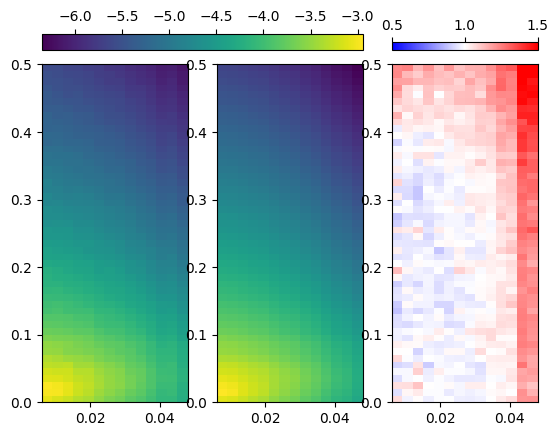

In [11]:
plt.rcParams.update({'font.size':10})
fig = plot_cy_power(
    kperpbins,
    kparabins,
    pdatacy_arr_1,
    pmodelcy_arr_1,
    0.5,
    1.5,
)

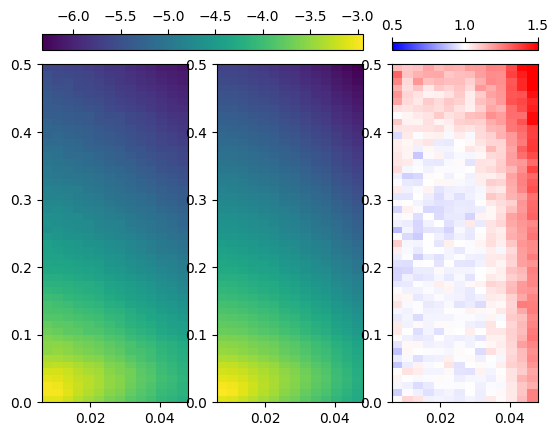

In [12]:
fig = plot_cy_power(
    kperpbins,
    kparabins,
    pdatacy_arr_2,
    pmodelcy_arr_2,
    0.5,
    1.5,
)

/home/zchen/meer21cm/papers/validation/specs.py:51: RuntimeWarning: invalid value encountered in log10
  np.log10(pdatacy.mean(axis=0).T),
/home/zchen/meer21cm/papers/validation/specs.py:60: RuntimeWarning: invalid value encountered in log10
  np.log10(pdatacy.mean(axis=0).T),


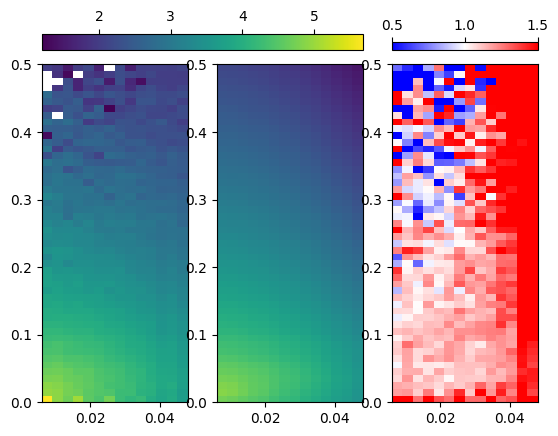

In [13]:
fig = plot_cy_power(
    kperpbins,
    kparabins,
    pgcy_arr_1,
    pgmodelcy_arr_1,
    0.5,
    1.5,
)

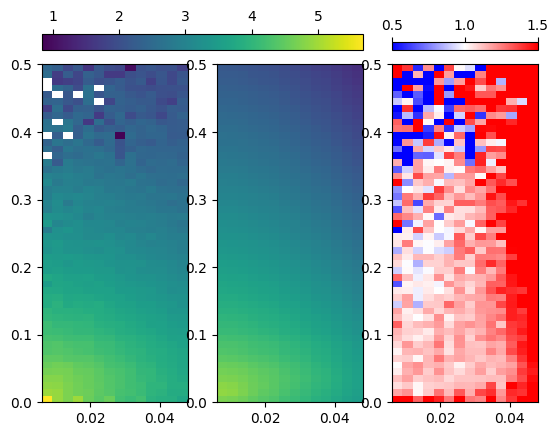

In [14]:
fig = plot_cy_power(
    kperpbins,
    kparabins,
    pgcy_arr_2,
    pgmodelcy_arr_2,
    0.5,
    1.5,
)

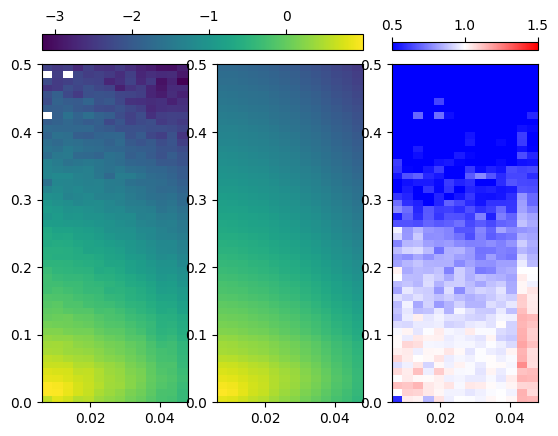

In [15]:
fig = plot_cy_power(
    kperpbins,
    kparabins,
    pxcy_arr_1,
    pxmodelcy_arr_1,
    0.5,
    1.5,
)

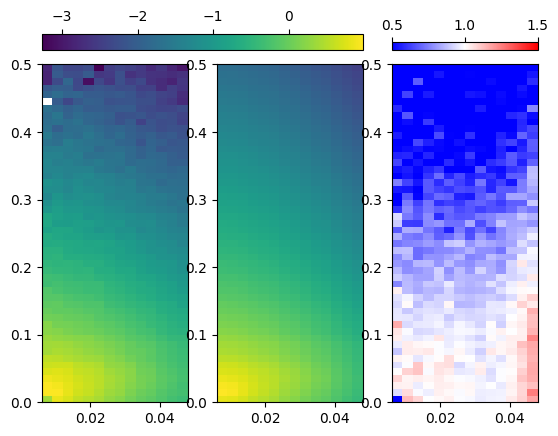

In [16]:
fig = plot_cy_power(
    kperpbins,
    kparabins,
    pxcy_arr_2,
    pxmodelcy_arr_2,
    0.5,
    1.5,
)

In [18]:
k_xy_sel_1 = (
    (np.abs(kvec_1[0])<0.016)[:,None,None] 
    * (np.abs(kvec_1[1])<0.016)[None,:,None]
    * (np.abs(kvec_1[2])<10)[None,None,:]
)
k_xy_sel_1[0] = 0.0
k_xy_sel_1[:,0] = 0.0
k_xy_sel_1[:,:,0] = 0.0
k_xy_sel_2 = (
    (np.abs(kvec_2[0])<0.016)[:,None,None] 
    * (np.abs(kvec_2[1])<0.016)[None,:,None]
    * (np.abs(kvec_2[2])<10)[None,None,:]
)
k_xy_sel_2[0] = 0.0
k_xy_sel_2[:,0] = 0.0
k_xy_sel_2[:,:,0] = 0.0


In [34]:
k1dbins = np.linspace(0.003, 0.2, 27)[1:]


In [35]:
pdata1darr, keff, nmodes = bin_power_1d(
    np.concatenate(
        [data['pdata3d_arr_1'].reshape((len(data['pdata3d_arr_1']),-1)),
        data['pdata3d_arr_2'].reshape((len(data['pdata3d_arr_2']),-1))],
        axis=1
    ),
    np.concatenate([kmode_1.ravel(),kmode_2.ravel()]),
    k1dbins,
    np.concatenate([k_xy_sel_1.ravel(),k_xy_sel_2.ravel()]),
)
pmod1darr, keff, nmodes = bin_power_1d(
    np.concatenate(
        [(data['phimod3d_arr_1'][0]).ravel()[None],
        (data['phimod3d_arr_2'][0]).ravel()[None]],
        axis=1
    ),
    np.concatenate([kmode_1.ravel(),kmode_2.ravel()]),
    k1dbins,
    np.concatenate([k_xy_sel_1.ravel(),k_xy_sel_2.ravel()]),
)
pmod1darr = pmod1darr[0]


pg1darr, keff, nmodes = bin_power_1d(
    np.concatenate(
        [data['pg3d_arr_1'].reshape((len(data['pg3d_arr_1']),-1)),
        data['pg3d_arr_2'].reshape((len(data['pg3d_arr_2']),-1))],
        axis=1
    ),
    np.concatenate([kmode_1.ravel(),kmode_2.ravel()]),
    k1dbins,
    np.concatenate([k_xy_sel_1.ravel(),k_xy_sel_2.ravel()]),
)
pgmod1darr, keff, nmodes = bin_power_1d(
    np.concatenate(
        [(data['pgmod3d_arr_1'][0]).ravel()[None],
        (data['pgmod3d_arr_2'][0]).ravel()[None]],
        axis=1
    ),
    np.concatenate([kmode_1.ravel(),kmode_2.ravel()]),
    k1dbins,
    np.concatenate([k_xy_sel_1.ravel(),k_xy_sel_2.ravel()]),
)
pgmod1darr = pgmod1darr[0]

px1darr, keff, nmodes = bin_power_1d(
    np.concatenate(
        [data['pcross3d_arr_1'].reshape((len(data['pcross3d_arr_1']),-1)),
        data['pcross3d_arr_2'].reshape((len(data['pcross3d_arr_2']),-1))],
        axis=1
    ),
    np.concatenate([kmode_1.ravel(),kmode_2.ravel()]),
    k1dbins,
    np.concatenate([k_xy_sel_1.ravel(),k_xy_sel_2.ravel()]),
)
pxmod1darr, keff, nmodes = bin_power_1d(
    np.concatenate(
        [(data['pcrossmod3d_arr_1'][0]).ravel()[None],
        (data['pcrossmod3d_arr_2'][0]).ravel()[None]],
        axis=1
    ),
    np.concatenate([kmode_1.ravel(),kmode_2.ravel()]),
    k1dbins,
    np.concatenate([k_xy_sel_1.ravel(),k_xy_sel_2.ravel()]),
)
pxmod1darr = pxmod1darr[0]

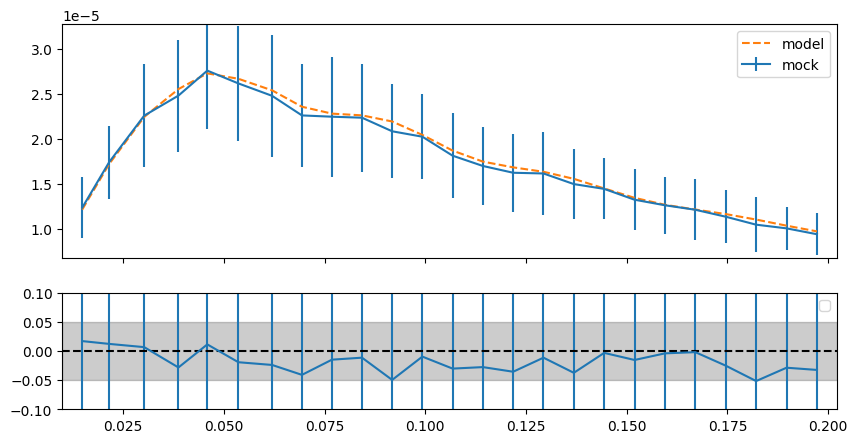

In [36]:
plot_1d_power(
        keff,
        pdata1darr,
        pmod1darr,
        -0.1,
        0.1,
    );

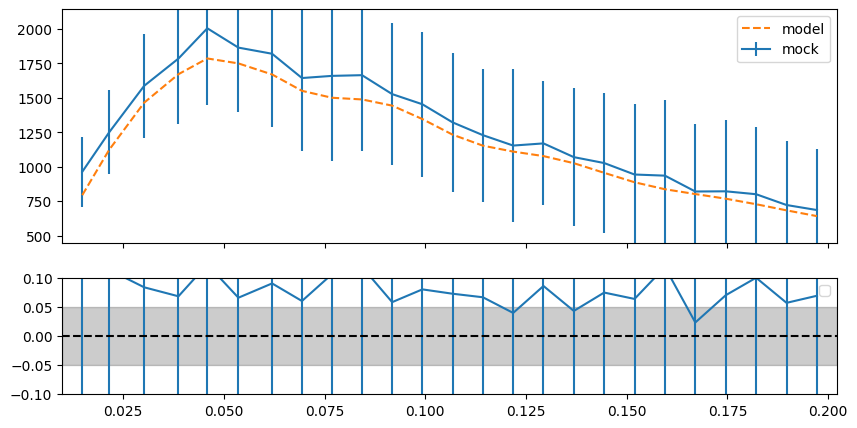

In [37]:
plot_1d_power(
        keff,
    pg1darr,
        pgmod1darr,
        -0.1,
        0.1,
    );

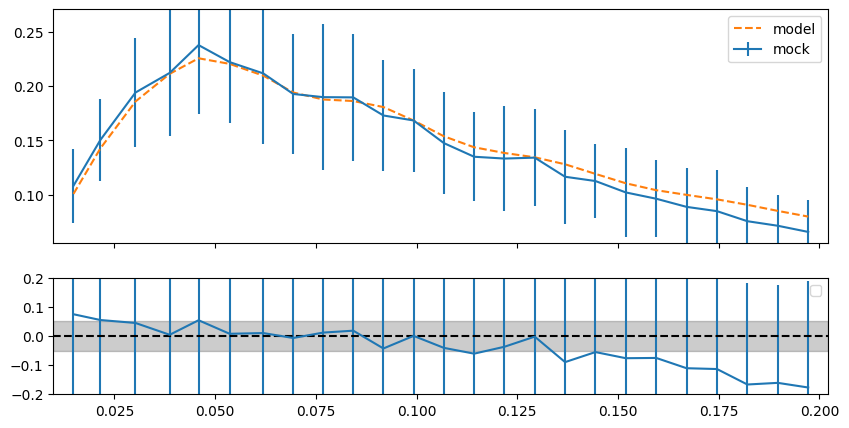

In [38]:
plot_1d_power(
        keff,
        px1darr,
        pxmod1darr,
        -0.2,
        0.2,
    );

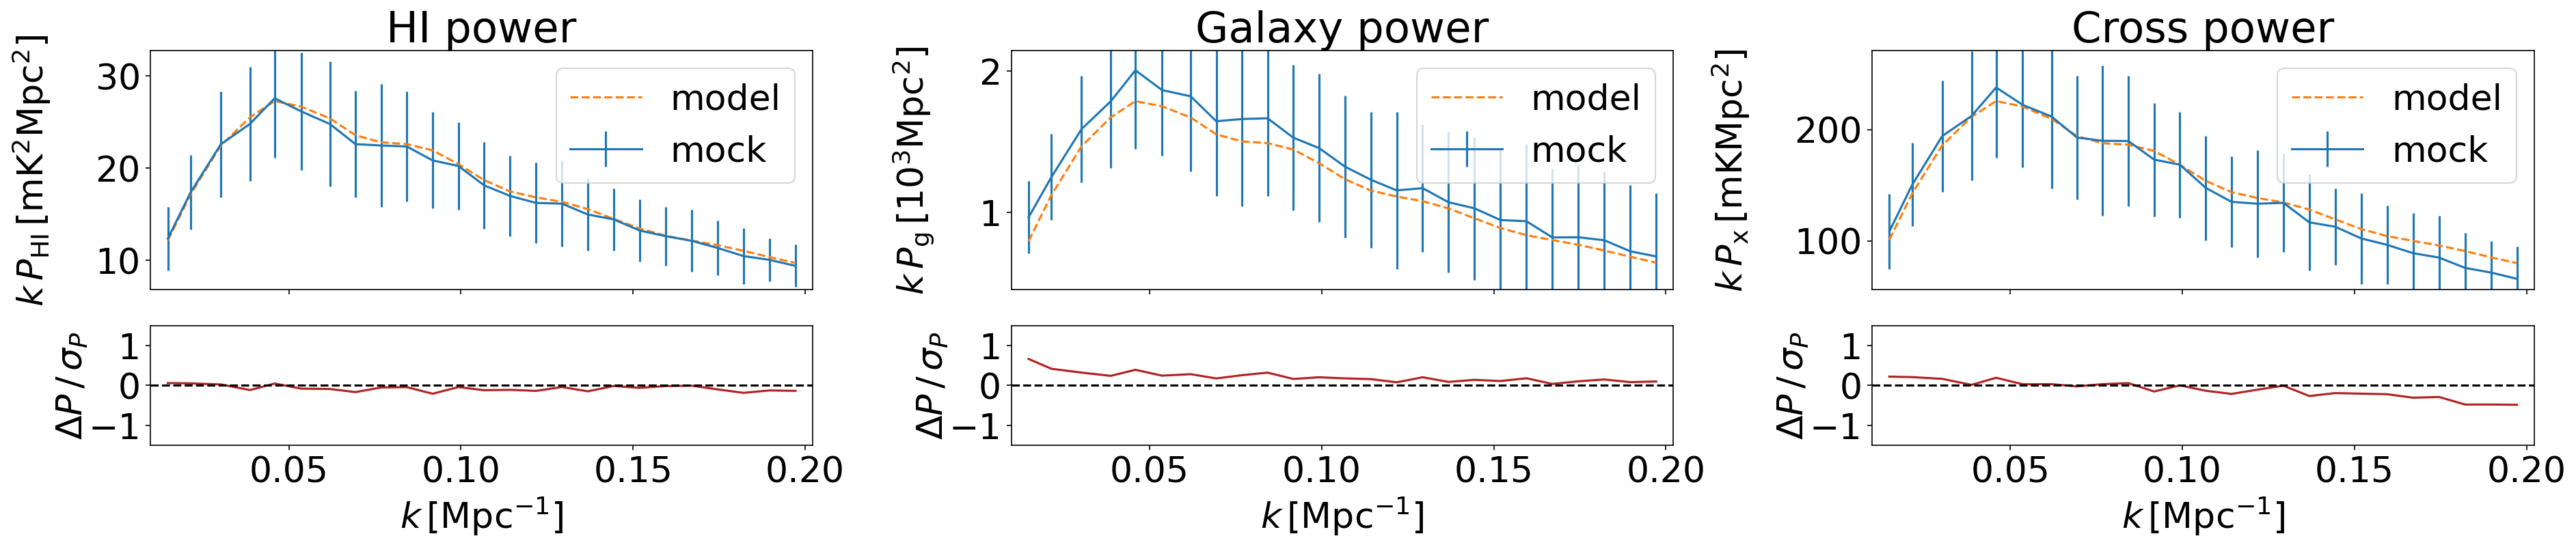

In [39]:
plt.rcParams['font.size'] = 25
fig,axes=plt.subplots(
    2,3,figsize=(30,5),sharex=True,
    height_ratios=[2,1],dpi=150,
    gridspec_kw={'wspace':0.3},
)
ratio_min,ratio_max = (-1.5,1.5)
pmockarr = [pdata1darr*1e6,pg1darr/1e3,px1darr*1e3]
pmodelarr = [pmod1darr*1e6,pgmod1darr/1e3,pxmod1darr*1e3]
titlearr = [r'HI power',r'Galaxy power',r'Cross power']
ylabelarr= [
    r'$k\,P_{\rm HI}\,[{\rm mK^2 Mpc^2}]$',
    r'$k\,P_{\rm g}\,[{\rm 10^3 Mpc^2}]$',
    r'$k\,P_{\rm x}\,[{\rm mK Mpc^2}]$',
]
for i in range(3):
    pdatad = pmockarr[i]
    pmodd = pmodelarr[i]
    axes[0,i].errorbar(
        keff,
        pdatad.mean(axis=0) * keff,
        yerr=pdatad.std(axis=0) * keff,
        label="mock",
    )
    axes[0,i].plot(keff, pmodd * keff, label="model", ls="--")
    ylim = (np.nanmin(pmodd * keff) * 0.7, np.nanmax(pmodd * keff) * 1.2)
    axes[0,i].set_ylim(ylim)
    axes[0,i].legend()
    axes[0,i].set_ylabel(ylabelarr[i],labelpad=30)
    axes[0,i].set_title(titlearr[i])
    axes[1,i].plot(
        keff,
        (pdatad.mean(axis=0)- pmodd) / (pdatad.std(axis=0)),
        #yerr=(pdatad.std(axis=0)) / (pmodd) / np.sqrt(len(pdatad)),
        color='firebrick',
    )
    axes[1,i].axhline(0, color="black", ls="--")
    #axes[1,i].fill_between(
    #    np.linspace(keff.min()-0.005,keff.max()+0.005,100), 
    #    -0.05, 0.05, color="black", alpha=0.2,
    #)
    #axes[1,i].fill_between(
    #    np.linspace(keff.min()-0.005,keff.max()+0.005,100), 
    #    -0.02, 0.02, color="black", alpha=0.2,
    #)
    xlim = (np.nanmin(keff)-0.005,np.nanmax(keff)+0.005)
    axes[1,i].set_xlim(xlim)
    axes[1,i].set_ylim(ratio_min,ratio_max)
    axes[1,i].set_ylabel(r'$\Delta P \, / \,\sigma_P$',labelpad=-1)
    axes[1,i].set_xlabel(r'$k\,[{\rm Mpc^{-1}}]$')
#plt.savefig('plots/mock_validation_1d.pdf',dpi=150, bbox_inches = "tight")

In [ ]:
# nobeam: dndz_box>0 * box_counts for grid
# test: dnddz_box>0 * box_counts>0 for grid